In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [65]:
df = pd.read_excel("ames_housing_data (1).xlsx")

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SID            2930 non-null   int64  
 1   PID            2930 non-null   int64  
 2   SubClass       2930 non-null   int64  
 3   Zoning         2930 non-null   object 
 4   LotFrontage    2440 non-null   float64
 5   LotArea        2930 non-null   int64  
 6   Street         2930 non-null   object 
 7   Alley          198 non-null    object 
 8   LotShape       2930 non-null   object 
 9   LandContour    2930 non-null   object 
 10  Utilities      2930 non-null   object 
 11  LotConfig      2930 non-null   object 
 12  LandSlope      2930 non-null   object 
 13  Neighborhood   2930 non-null   object 
 14  Condition1     2930 non-null   object 
 15  Condition2     2930 non-null   object 
 16  BldgType       2930 non-null   object 
 17  HouseStyle     2930 non-null   object 
 18  OverallQ

In [67]:
#Feature Engineering
df["TotalFloorSF"] = df["FirstFlrSF"] + df["SecondFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["QualityIndex"] = df["OverallQual"] * df["OverallCond"]
df["logSalePrice"] = np.log(df["SalePrice"])
df["price_sqft"] = df["SalePrice"] / df["TotalFloorSF"]



In [68]:
#Drop conditions
df_sample = df[
    df["Zoning"].isin(["RH", "RL", "RP", "RM"]) &
    (df["SaleCondition"] == "Normal") &
    (df["Functional"] == "Typ") &
    (df["BldgType"] == "1Fam") &
    (df["SalePrice"] <= 335000) &
    (df["GrLivArea"] < 4000)
].copy()

In [69]:
df_sample.shape

(1722, 87)

| Step | Drop Condition Applied                     | Observations Remaining |
|-----:|-------------------------------------------|------------------------:|
| 1    | Full dataset                              | 2,930                   |
| 2    | Residential properties only              | 2,762                   |
| 3    | Normal sale condition only               | 2,305                   |
| 4    | Typical home functionality only          | 2,138                   |
| 5    | Single-family homes only                 | 1,794                   |
| 6    | SalePrice ≤ $335,000                     | 1,722                   |


In [70]:
#Missing value check
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_sample.isna().sum().sort_values(ascending = False)

PoolQC           1718
MiscFeature      1651
Alley            1631
Fence            1310
MasVnrType       1091
FireplaceQu       833
LotFrontage       345
GarageCond         61
GarageFinish       61
GarageQual         61
GarageYrBlt        61
GarageType         61
BsmtExposure       24
BsmtFinType2       23
BsmtCond           22
BsmtQual           22
BsmtFinType1       22
MasVnrArea          9
BsmtFullBath        1
Electrical          1
BsmtHalfBath        1
OpenPorchSF         0
FullBath            0
HalfBath            0
BedroomAbvGr        0
KitchenAbvGr        0
KitchenQual         0
TotRmsAbvGrd        0
Functional          0
Fireplaces          0
logSalePrice        0
QualityIndex        0
HouseAge            0
TotalFloorSF        0
EnclosedPorch       0
SaleCondition       0
SaleType            0
YrSold              0
MoSold              0
GarageCars          0
GarageArea          0
MiscVal             0
PoolArea            0
ScreenPorch         0
ThreeSsnPorch       0
PavedDrive

In [75]:
#Categorical variables with None category
df_sample["PoolQC"] = df_sample["PoolQC"].fillna("None")
df_sample["MiscFeature"] = df_sample["MiscFeature"].fillna("None")
df_sample["Alley"] = df_sample["Alley"].fillna("None")
df_sample["Fence"] = df_sample["Fence"].fillna("None")
df_sample["FireplaceQu"] = df_sample["FireplaceQu"].fillna("None")
df_sample["MasVnrType"] = df_sample["MasVnrType"].fillna("None")
df_sample["GarageFinish"] = df_sample["GarageFinish"].fillna("None")
df_sample["GarageCond"] = df_sample["GarageCond"].fillna("None")
df_sample["GarageQual"] = df_sample["GarageQual"].fillna("None")
df_sample["GarageType"] = df_sample["GarageType"].fillna("None")
df_sample["BsmtExposure"] = df_sample["BsmtExposure"].fillna("None")
df_sample["BsmtFinType1"] = df_sample["BsmtFinType1"].fillna("None")
df_sample["BsmtFinType2"] = df_sample["BsmtFinType2"].fillna("None")
df_sample["BsmtCond"] = df_sample["BsmtFinType1"].fillna("None")
df_sample["BsmtQual"] = df_sample["BsmtFinType1"].fillna("None")
df_sample["Electrical"] = df_sample["Electrical"].fillna("None")


In [76]:
cat_vars = df_sample.select_dtypes(include = "object")

In [77]:
cat_vars.isna().sum().sort_values(ascending = False)

Zoning           0
FireplaceQu      0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
GarageType       0
BsmtCond         0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
PoolQC           0
Fence            0
MiscFeature      0
SaleType         0
BsmtExposure     0
BsmtQual         0
Street           0
Condition2       0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
BldgType         0
Foundation       0
HouseStyle       0
RoofStyle        0
RoofMat          0
Exterior1        0
Exterior2        0
MasVnrType       0
ExterQual        0
ExterCond        0
SaleCondition    0
dtype: int64

In [78]:
num_vars = df_sample.select_dtypes(include = ["int64","float64"])

In [79]:
num_vars.isna().sum().sort_values(ascending = False)

LotFrontage      345
GarageYrBlt       61
MasVnrArea         9
BsmtHalfBath       1
BsmtFullBath       1
SID                0
ScreenPorch        0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
ThreeSsnPorch      0
PoolArea           0
TotRmsAbvGrd       0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
TotalFloorSF       0
HouseAge           0
QualityIndex       0
logSalePrice       0
Fireplaces         0
BedroomAbvGr       0
KitchenAbvGr       0
BsmtFinSF2         0
SubClass           0
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodel        0
BsmtFinSF1         0
BsmtUnfSF          0
PID                0
TotalBsmtSF        0
FirstFlrSF         0
SecondFlrSF        0
LowQualFinSF       0
GrLivArea          0
FullBath           0
HalfBath           0
price_sqft         0
dtype: int64

In [81]:
df_sample["LotFrontage"] = df_sample["LotFrontage"].fillna(df_sample["LotFrontage"].median())

In [82]:
# Garage year built
df_sample["GarageYrBlt"] = df_sample["GarageYrBlt"].fillna(df_sample["YearBuilt"])

# Masonry veneer area
df_sample["MasVnrArea"] = df_sample["MasVnrArea"].fillna(0)

# Basement bathrooms
df_sample["BsmtHalfBath"] = df_sample["BsmtHalfBath"].fillna(0)
df_sample["BsmtFullBath"] = df_sample["BsmtFullBath"].fillna(0)

In [86]:
df_sample.isna().sum()

SID              0
PID              0
SubClass         0
Zoning           0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodel      0
RoofStyle        0
RoofMat          0
Exterior1        0
Exterior2        0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
FirstFlrSF       0
SecondFlrSF      0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr

In [89]:
#Model for only continous variables.
df_sample1 = df_sample[[
    'SalePrice',
    'logSalePrice',
    'LotFrontage',
    'LotArea',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'FirstFlrSF',
    'SecondFlrSF',
    'LowQualFinSF',
    'GrLivArea',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'ThreeSsnPorch',
    'ScreenPorch',
    'PoolArea',
    'MiscVal',
    'TotalFloorSF',
    'price_sqft',
    'OverallQual',
    'TotalBsmtSF'
]].copy()


In [90]:
df_sample1.isna().sum()

SalePrice        0
logSalePrice     0
LotFrontage      0
LotArea          0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
FirstFlrSF       0
SecondFlrSF      0
LowQualFinSF     0
GrLivArea        0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
ThreeSsnPorch    0
ScreenPorch      0
PoolArea         0
MiscVal          0
TotalFloorSF     0
price_sqft       0
OverallQual      0
TotalBsmtSF      0
dtype: int64

In [95]:
zero_proportion = (df_sample1 == 0).sum() / len(df_sample1)
print(zero_proportion)

SalePrice        0.000000
logSalePrice     0.000000
LotFrontage      0.000000
LotArea          0.000000
MasVnrArea       0.631243
BsmtFinSF1       0.293264
BsmtFinSF2       0.864692
BsmtUnfSF        0.063879
FirstFlrSF       0.000000
SecondFlrSF      0.568525
LowQualFinSF     0.990128
GrLivArea        0.000000
GarageArea       0.035424
WoodDeckSF       0.527294
OpenPorchSF      0.474448
ThreeSsnPorch    0.987224
ScreenPorch      0.910569
PoolArea         0.997677
MiscVal          0.959930
TotalFloorSF     0.000000
price_sqft       0.000000
OverallQual      0.000000
TotalBsmtSF      0.012776
dtype: float64


In [96]:
#Drop variables who have of proportions of zero relative to total rows greater than 0.05
cols_to_keep = zero_proportion[zero_proportion < 0.05].index
df_sample2 = df_sample1[cols_to_keep].copy()

print("Columns retained:", list(df_sample2.columns))

Columns retained: ['SalePrice', 'logSalePrice', 'LotFrontage', 'LotArea', 'FirstFlrSF', 'GrLivArea', 'GarageArea', 'TotalFloorSF', 'price_sqft', 'OverallQual', 'TotalBsmtSF']


In [97]:
df_sample2.corr()

,SalePrice,logSalePrice,LotFrontage,LotArea,FirstFlrSF,GrLivArea,GarageArea,TotalFloorSF,price_sqft,OverallQual,TotalBsmtSF
SalePrice,1.000000,0.975209,0.347762,0.335706,0.601606,0.775083,0.616373,0.781430,0.358799,0.789746,0.570947
logSalePrice,0.975209,1.000000,0.351020,0.328884,0.587185,0.765742,0.614314,0.772007,0.362337,0.791265,0.562680
LotFrontage,0.347762,0.351020,1.000000,0.238588,0.387972,0.252328,0.298909,0.256212,0.156821,0.235941,0.274247
LotArea,0.335706,0.328884,0.238588,1.000000,0.319344,0.260210,0.200505,0.262067,0.132319,0.145809,0.231491
FirstFlrSF,0.601606,0.587185,0.387972,0.319344,1.000000,0.453872,0.429142,0.456341,0.236723,0.414611,0.768931
GrLivArea,0.775083,0.765742,0.252328,0.260210,0.453872,1.000000,0.427538,0.996883,-0.277081,0.612701,0.303053
GarageArea,0.616373,0.614314,0.298909,0.200505,0.429142,0.427538,1.000000,0.430528,0.312796,0.496582,0.407090
TotalFloorSF,0.781430,0.772007,0.256212,0.262067,0.456341,0.996883,0.430528,1.000000,-0.273543,0.619038,0.307429
price_sqft,0.358799,0.362337,0.156821,0.132319,0.236723,-0.277081,0.312796,-0.273543,1.000000,0.266439,0.387835
OverallQual,0.789746,0.791265,0.235941,0.145809,0.414611,0.612701,0.496582,0.619038,0.266439,1.000000,0.424270


In [101]:
model1 = smf.ols("SalePrice ~ TotalFloorSF", data=df_sample2).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     2697.
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:08:43   Log-Likelihood:                -20447.
No. Observations:                1722   AIC:                         4.090e+04
Df Residuals:                    1720   BIC:                         4.091e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3.259e+04   2794.738     11.662   

In [110]:
anova_lm(model1)


,df,sum_sq,mean_sq,F,PR(>F)
TotalFloorSF,1.0,3.256204e+12,3.256204e+12,2697.422329,0.0
Residual,1720.0,2.076305e+12,1.207154e+09,NaN,NaN


Text(0.5, 1.0, 'SalePrice vs TotalFLoorSF')

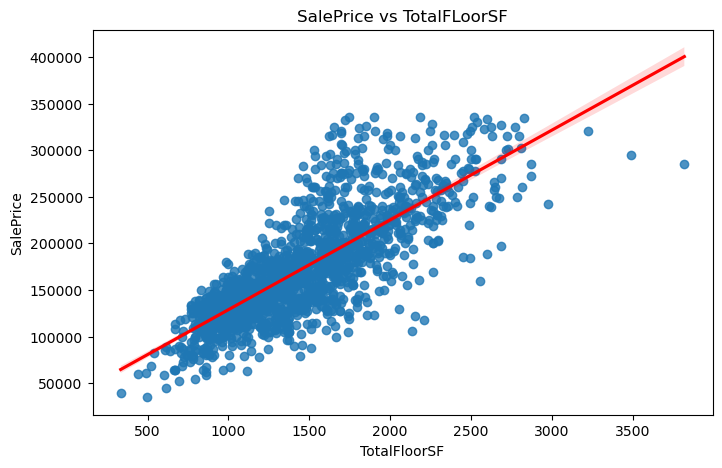

In [107]:
plt.figure(figsize = (8,5))
sns.regplot(x = df_sample2["TotalFloorSF"], y = df_sample2["SalePrice"], line_kws = {"color":"red"})
plt.xlabel("TotalFloorSF")
plt.ylabel("SalePrice")
plt.title("SalePrice vs TotalFLoorSF")


In [116]:
t_critical_two = stats.t.ppf(1 - 0.05 / 2, 1721)
t_critical_two

1.9613433640447577

In [120]:
f_critical = stats.f.ppf(q=1-.05, dfn=1, dfd=1720)
f_critical

3.846870939716221

In [121]:
f_stat =((5332509000000 - 2076305000000) / 1) / (2076305000000/(1722-1-1))
f_stat

2697.4220454124033

In [122]:
pred1 = model1.fittedvalues

In [123]:
y_hat = 32590 + 96.2606 * df_sample2["TotalFloorSF"]

In [124]:
resid1 = model1.resid
resid1_hand = df_sample2["TotalFloorSF"] - y_hat

In [125]:
std_resid1 = resid1 / resid1.std()

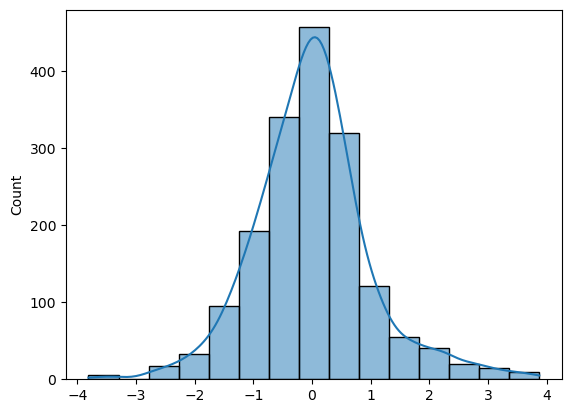

In [126]:
sns.histplot(std_resid1, bins=15, kde=True)
plt.show()

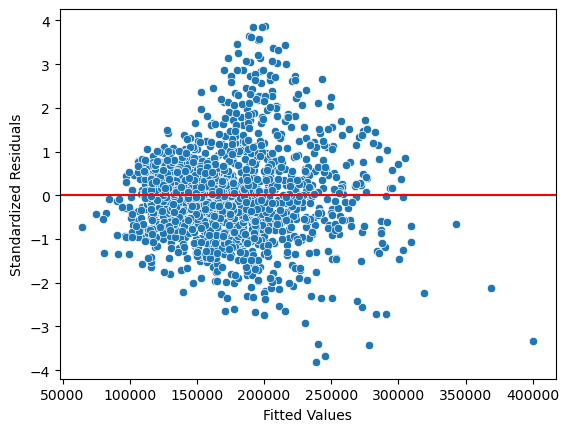

In [127]:
sns.scatterplot(x=pred1, y=std_resid1)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

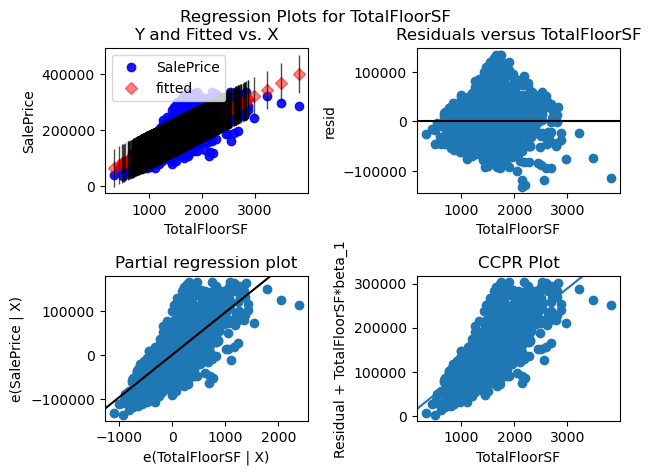

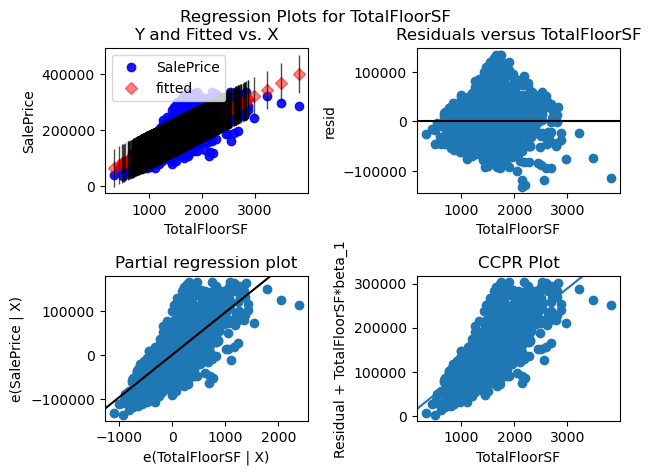

In [128]:
sm.graphics.plot_regress_exog(model1, "TotalFloorSF")

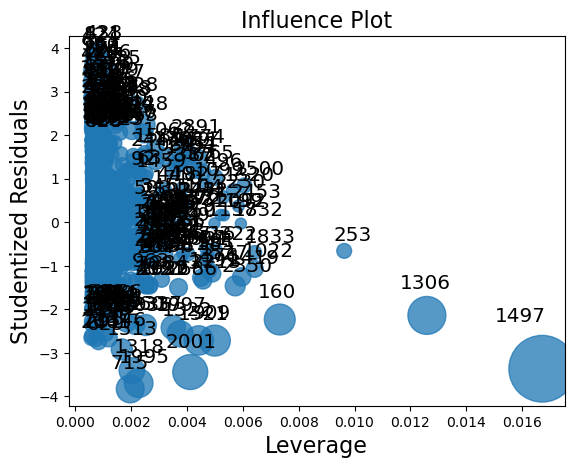

In [129]:
sm.graphics.influence_plot(model1, criterion="cooks")
plt.show()

In [130]:
#Model 2: TotalFloorSF and OverQual
model2 = smf.ols("SalePrice ~ TotalFloorSF + OverallQual", data = df_sample2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     2759.
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:47:52   Log-Likelihood:                -20022.
No. Observations:                1722   AIC:                         4.005e+04
Df Residuals:                    1719   BIC:                         4.007e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -5.045e+04   3323.437    -15.181   

In [131]:
#Model 2 - Anova
anova_lm(model2)

,df,sum_sq,mean_sq,F,PR(>F)
TotalFloorSF,1.0,3.256204e+12,3.256204e+12,4418.864418,0.000000e+00
OverallQual,1.0,8.095959e+11,8.095959e+11,1098.670306,1.065042e-186
Residual,1719.0,1.266709e+12,7.368871e+08,NaN,NaN


In [141]:
y_hat2 = -50450 + 58.4272 * df_sample2["TotalFloorSF"] + 23130 * df_sample2["OverallQual"]

In [132]:
#stats.t.ppf(1 - alpha / 2, df)
t_critical_model2 = stats.t.ppf(1 - 0.05 / 2, 1721)
t_critical_model2

1.9613433640447577

In [136]:
f_stat =((5332508900000 - 1266709000000) / 2) / (1266709000000/(1722-2-1))
f_stat

2758.7670207206233

In [140]:
f_critical2 = stats.f.ppf(q=1-.05, dfn=2, dfd=1719)
f_critical2

3.0009590609456924

In [142]:
#Model predictions
pred2 = model2.fittedvalues

In [143]:
#Residuals
resid2 = model2.resid
resid2_hand = df_sample2["TotalFloorSF"] + df_sample2["OverallQual"] - y_hat2

In [144]:
#Standardized Residuals
std_resid2 = resid2 / resid2.std()

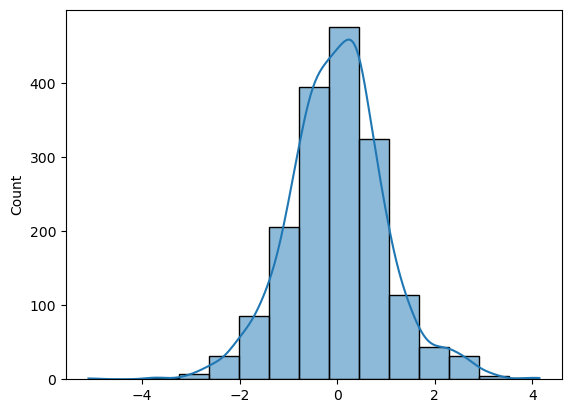

In [145]:
sns.histplot(std_resid2, bins=15, kde=True)
plt.show()

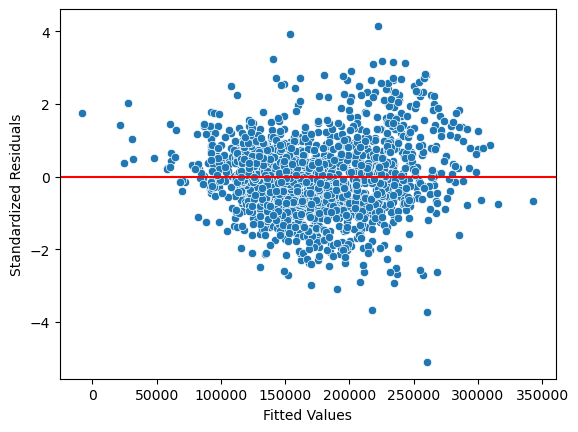

In [146]:
sns.scatterplot(x=pred2, y=std_resid2)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

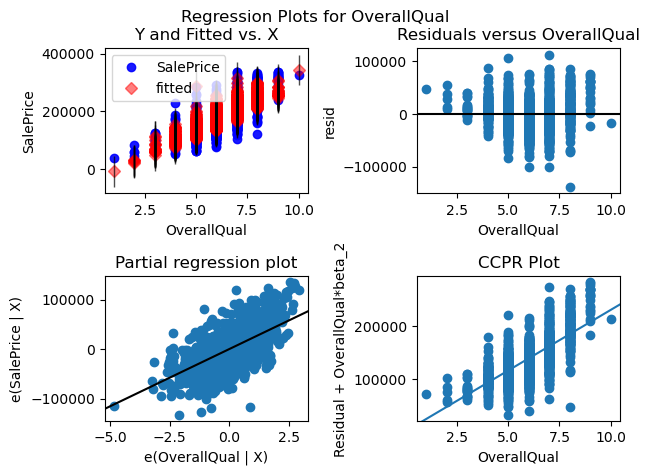

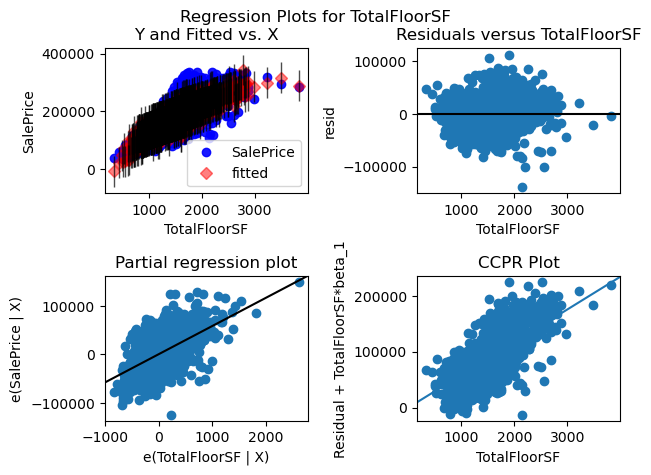

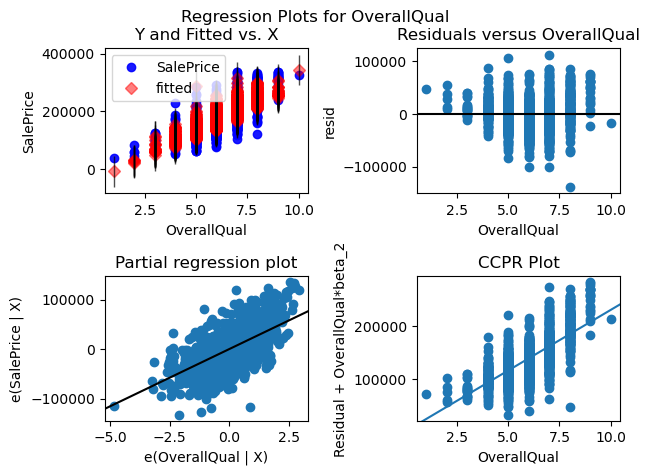

In [148]:
sm.graphics.plot_regress_exog(model2, "TotalFloorSF")
sm.graphics.plot_regress_exog(model2, "OverallQual")

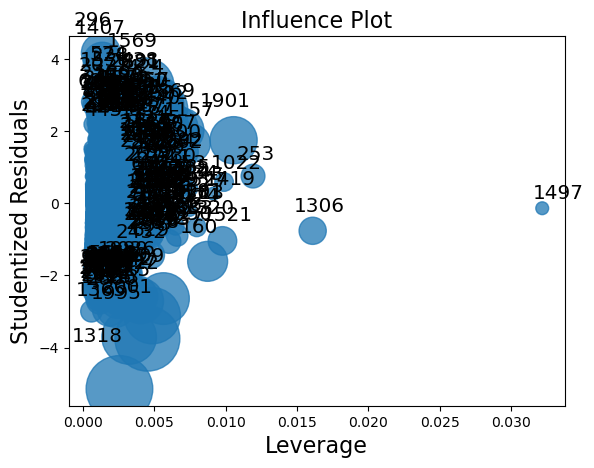

In [150]:
sm.graphics.influence_plot(model2, criterion="cooks")
plt.show()

In [152]:
#Model 3: TotalFloorSF~OverQual~TotalBsmtSF
model3 = smf.ols("SalePrice ~ TotalFloorSF + OverallQual + TotalBsmtSF", data = df_sample2).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     2589.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:13:35   Log-Likelihood:                -19788.
No. Observations:                1722   AIC:                         3.958e+04
Df Residuals:                    1718   BIC:                         3.961e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -6.212e+04   2946.489    -21.083   

In [153]:
#Model 3 - Anova
anova_lm(model3)

,df,sum_sq,mean_sq,F,PR(>F)
TotalFloorSF,1.0,3.256204e+12,3.256204e+12,5791.514074,0.000000e+00
OverallQual,1.0,8.095959e+11,8.095959e+11,1439.954690,2.237813e-229
TotalBsmtSF,1.0,3.007855e+11,3.007855e+11,534.979895,2.898194e-103
Residual,1718.0,9.659233e+11,5.622371e+08,NaN,NaN


In [154]:
#Model 3 predicted equation
y_hat3 = -62120 + 56.0764 * df_sample2["TotalFloorSF"] + 18480 * df_sample2["OverallQual"] + 42.2128 * df_sample2["TotalBsmtSF"]

In [155]:
#stats.t.ppf(1 - alpha / 2, df)
t_critical_model3 = stats.t.ppf(1 - 0.05 / 2, 1721)
t_critical_model3

1.9613433640447577

In [157]:
f_stat3 =((5332508700000 - 965923300000) / 3) / (965923300000/(1722-3-1))
f_stat3

2588.816219396854

In [158]:
f_critical3 = stats.f.ppf(q=1-.05, dfn=3, dfd=1718)
f_critical3

2.610081932376322

In [159]:
#Model predictions
pred3 = model3.fittedvalues

In [160]:
#Residuals
resid3 = model3.resid
resid3_hand = df_sample2["TotalFloorSF"] + df_sample2["OverallQual"] + df_sample2["TotalBsmtSF"] - y_hat3

In [161]:
#Standardized Residuals
std_resid3 = resid3 / resid3.std()

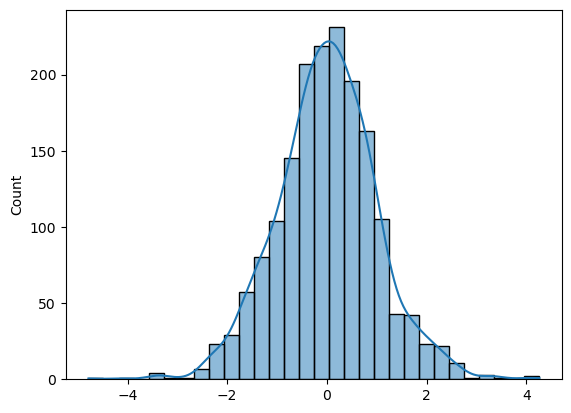

In [162]:
sns.histplot(std_resid3, bins=30, kde=True)
plt.show()

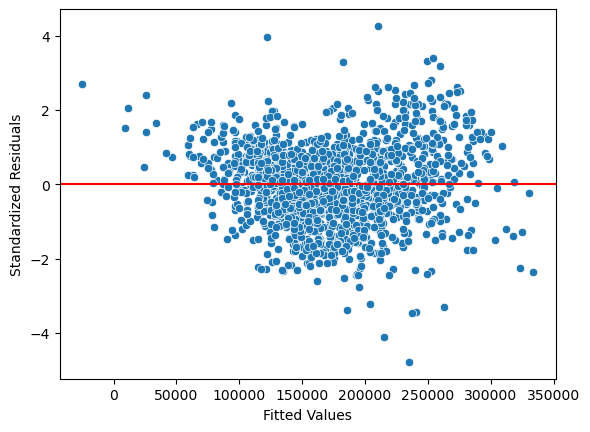

In [163]:
sns.scatterplot(x=pred3, y=std_resid3)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

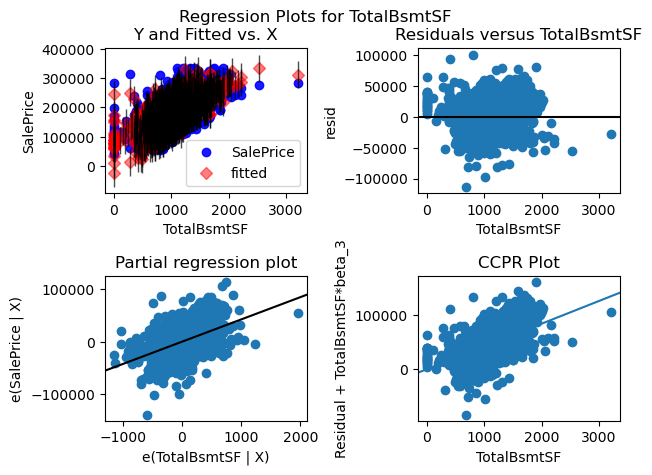

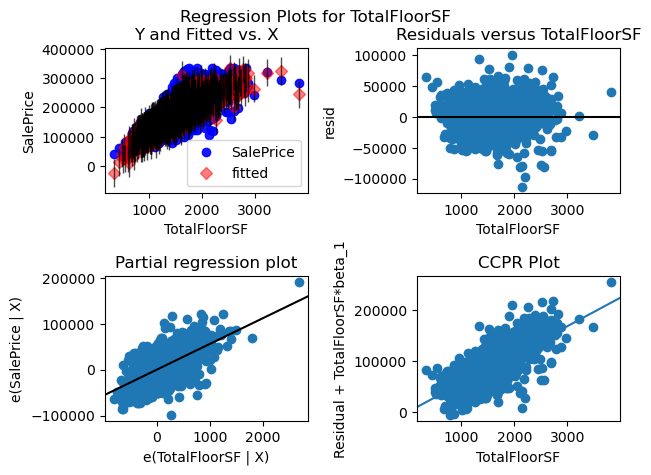

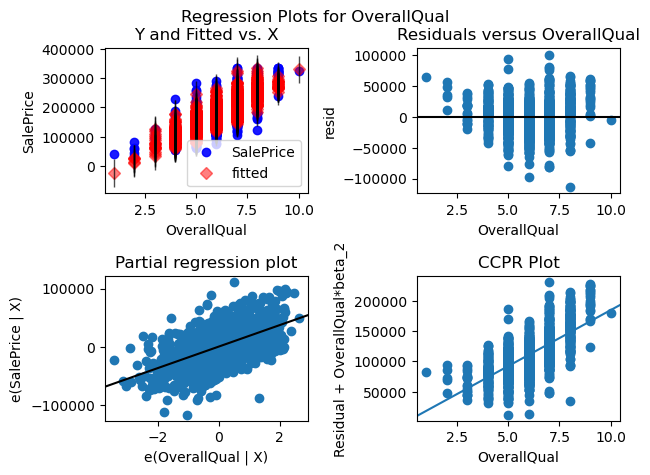

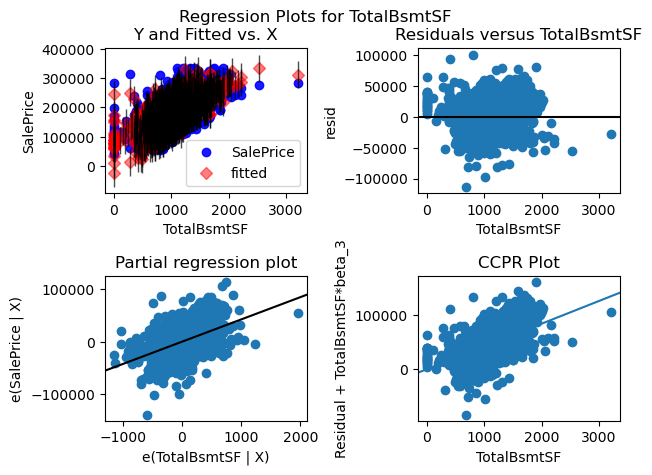

In [164]:
sm.graphics.plot_regress_exog(model3, "TotalFloorSF")
sm.graphics.plot_regress_exog(model3, "OverallQual")
sm.graphics.plot_regress_exog(model3, "TotalBsmtSF")

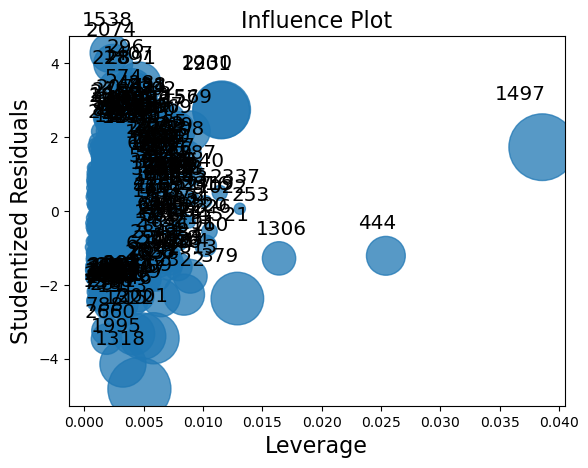

In [165]:
sm.graphics.influence_plot(model3, criterion="cooks")
plt.show()

In [166]:
#Model 4: TotalFloorSF~OverQual~TotalBsmtSF (LogSalePrice)
model4 = smf.ols("logSalePrice ~ TotalFloorSF + OverallQual + TotalBsmtSF", data = df_sample2).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:           logSalePrice   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     2401.
Date:                Sat, 31 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:15:37   Log-Likelihood:                 906.23
No. Observations:                1722   AIC:                            -1804.
Df Residuals:                    1718   BIC:                            -1783.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       10.6334      0.018    597.878   

In [167]:
anova_lm(model4)#Model predictions

,df,sum_sq,mean_sq,F,PR(>F)
TotalFloorSF,1.0,108.901984,108.901984,5316.274354,0.000000e+00
OverallQual,1.0,29.090459,29.090459,1420.110624,5.047791e-227
TotalBsmtSF,1.0,9.538035,9.538035,465.618824,1.415824e-91
Residual,1718.0,35.192617,0.020485,NaN,NaN


In [168]:
#Model predictions
pred4 = model4.fittedvalues

In [169]:
resid4 = model4.resid

In [170]:
#Standardized Residuals
std_resid4 = resid4 / resid4.std()

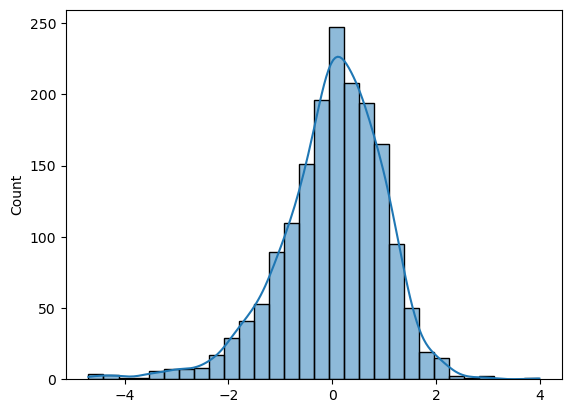

In [171]:
sns.histplot(std_resid4, bins=30, kde=True)
plt.show()

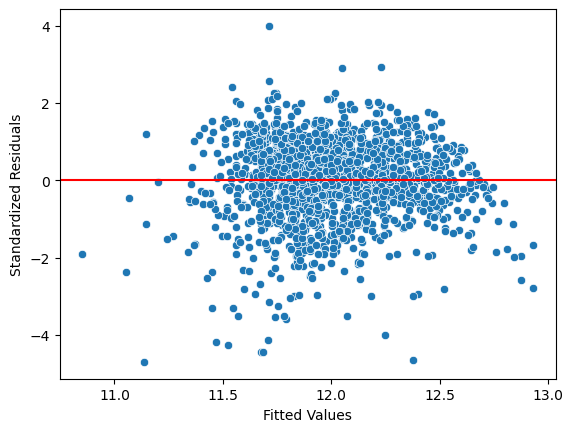

In [172]:
sns.scatterplot(x=pred4, y=std_resid4)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

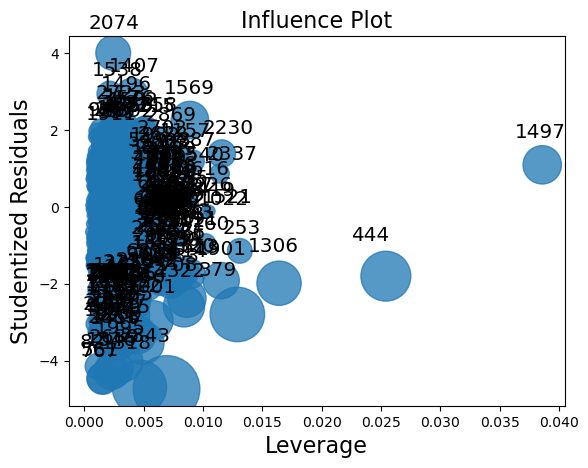

In [173]:
sm.graphics.influence_plot(model4, criterion="cooks")
plt.show()

In [174]:
influential_points = [1497, 444, 1306, 1318]

df_sample3 = df_sample2.drop(index=influential_points)

In [175]:
#Model 5: TotalFloorSF~OverQual~TotalBsmtSF
model5 = smf.ols("SalePrice ~ TotalFloorSF + OverallQual + TotalBsmtSF", data = df_sample3).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     2611.
Date:                Sat, 31 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:07:33   Log-Likelihood:                -19730.
No. Observations:                1718   AIC:                         3.947e+04
Df Residuals:                    1714   BIC:                         3.949e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -6.298e+04   2933.993    -21.467   

In [176]:
anova_lm(model5)

,df,sum_sq,mean_sq,F,PR(>F)
TotalFloorSF,1.0,3.255117e+12,3.255117e+12,5874.993557,0.000000e+00
OverallQual,1.0,7.897934e+11,7.897934e+11,1425.457595,1.580803e-227
TotalBsmtSF,1.0,2.944538e+11,2.944538e+11,531.444652,1.197109e-102
Residual,1714.0,9.496640e+11,5.540630e+08,NaN,NaN


In [178]:
model6 = smf.ols("SalePrice ~ TotalFloorSF + OverallQual + TotalBsmtSF + LotArea + LotFrontage", data = df_sample2).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     1704.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:33:16   Log-Likelihood:                -19722.
No. Observations:                1722   AIC:                         3.946e+04
Df Residuals:                    1716   BIC:                         3.949e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -7.604e+04   3314.534    -22.941   

In [179]:
anova_lm(model6)

,df,sum_sq,mean_sq,F,PR(>F)
TotalFloorSF,1.0,3.256204e+12,3.256204e+12,6250.945635,0.000000e+00
OverallQual,1.0,8.095959e+11,8.095959e+11,1554.183995,1.441338e-242
TotalBsmtSF,1.0,3.007855e+11,3.007855e+11,577.418996,3.194727e-110
LotArea,1.0,5.659222e+10,5.659222e+10,108.640276,1.044838e-24
LotFrontage,1.0,1.544297e+10,1.544297e+10,29.645920,5.935972e-08
Residual,1716.0,8.938881e+11,5.209138e+08,NaN,NaN


In [186]:
f_stat6 =((5332508690000 - 893888100000) / 5) / (893888100000/(1722-5-1))
f_stat6

1704.1669829680025

In [187]:
f_critical6 = stats.f.ppf(q=1-.05, dfn=5, dfd=1717)
f_critical6

2.219309319229094

In [180]:
#Model predictions
pred6 = model6.fittedvalues

In [181]:
resid6 = model6.resid

In [182]:
std_resid6 = resid6 / resid6.std()

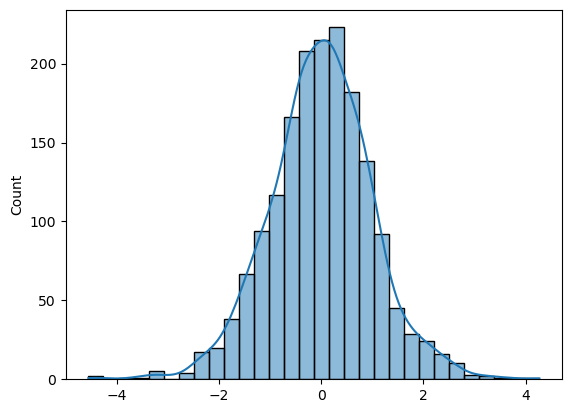

In [183]:
sns.histplot(std_resid6, bins=30, kde=True)
plt.show()

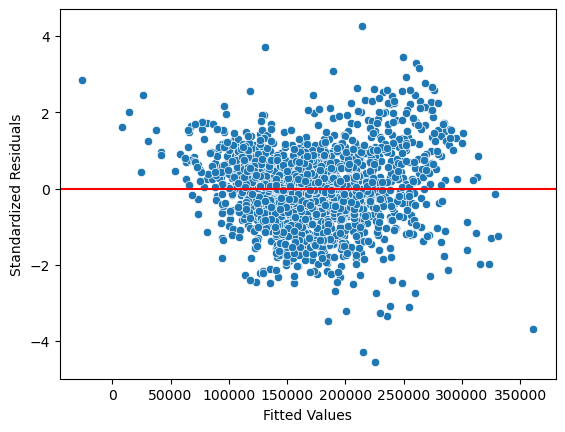

In [184]:
sns.scatterplot(x=pred6, y=std_resid6)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

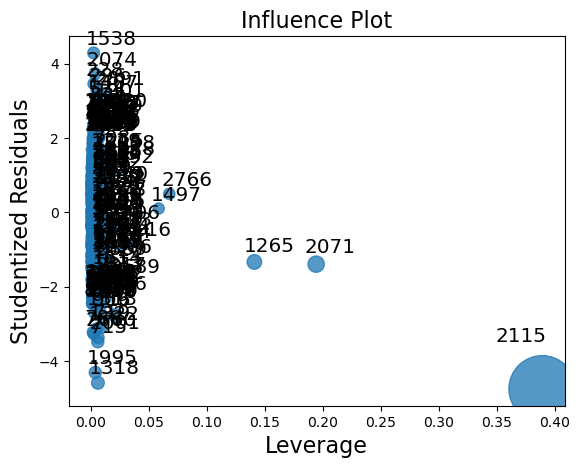

In [185]:
sm.graphics.influence_plot(model6, criterion="cooks")
plt.show()